In [ ]:
!pip install -q transformers torch torchvision datasets scikit-learn matplotlib seaborn

print("Libraries installed ✅")

Libraries installed ✅


In [ ]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print(f"Dataset downloaded to: {path}")


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root, len(files), "files")



/kaggle/input/skin-cancer-mnist-ham10000 5 files
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1 5000 files
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1 5000 files
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2 5015 files
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2 5015 files


In [ ]:
import pandas as pd

# Find the metadata CSV file
metadata_path = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv') and 'metadata' in file.lower():
            metadata_path = os.path.join(root, file)
            break

df = pd.read_csv(metadata_path)
print(f"Total images: {len(df)}")
print(df['dx'].value_counts())
df.head()


Total images: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
print("Total images:", len(df))
print("\nClass distribution:")
print(df['dx'].value_counts())


Total images: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
# Malignant: mel (melanoma), bcc (basal cell carcinoma), akiec (actinic keratoses)
# Benign: everything else
malignant_classes = ['mel', 'bcc', 'akiec']

df['binary_label'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)

print("Binary distribution:")
print(df['binary_label'].value_counts())
print(f"\nMalignant: {df['binary_label'].sum()} ({df['binary_label'].mean()*100:.1f}%)")
print(f"Benign: {(1-df['binary_label']).sum()} ({(1-df['binary_label'].mean())*100:.1f}%)")


Binary distribution:
binary_label
0    8061
1    1954
Name: count, dtype: int64

Malignant: 1954 (19.5%)
Benign: 8061 (80.5%)


In [ ]:
# Find image directories
image_dirs = []
for root, dirs, files in os.walk(path):
    if any(f.endswith('.jpg') for f in files[:5]):
        image_dirs.append(root)

print("Image directories found:")
for d in image_dirs:
    print(d)


Image directories found:
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2


In [ ]:
import glob

# Build a dictionary mapping image_id -> full file path
image_path_dict = {}
for img_dir in image_dirs:
    for img_path in glob.glob(os.path.join(img_dir, "*.jpg")):
        img_id = os.path.basename(img_path).replace(".jpg", "")
        image_path_dict[img_id] = img_path

df['path'] = df['image_id'].map(image_path_dict)

# Check how many matched
print(f"Total rows: {len(df)}")
print(f"Matched paths: {df['path'].notna().sum()}")
df[['image_id', 'path', 'binary_label']].head()

Total rows: 10015
Matched paths: 10015


,image_id,path,binary_label
0,ISIC_0027419,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,0
1,ISIC_0025030,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,0
2,ISIC_0026769,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,0
3,ISIC_0025661,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,0
4,ISIC_0031633,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,0


In [ ]:
from sklearn.model_selection import train_test_split

# 80/20 split, stratified to maintain class balance
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['binary_label']
)

print(f"Train: {len(train_df)} images")
print(f"Test: {len(test_df)} images")
print(f"\nTrain malignant: {train_df['binary_label'].mean()*100:.1f}%")
print(f"Test malignant: {test_df['binary_label'].mean()*100:.1f}%")


Train: 8012 images
Test: 2003 images

Train malignant: 19.5%
Test malignant: 19.5%


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = row['binary_label']

        if self.transform:
            image = self.transform(image)

        return image, label

print("Dataset class created ✅")


Dataset class created ✅


In [ ]:
from torchvision import transforms

# Standard ImageNet normalization (used by both CNN and ViT pretrained models)
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined ✅")

Transforms defined ✅


In [ ]:
from torch.utils.data import DataLoader

train_dataset = SkinCancerDataset(train_df, transform=train_transform)
test_dataset = SkinCancerDataset(test_df, transform=test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Quick sanity check
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Train batches: 251
Test batches: 63

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [ ]:
import torch.nn as nn

class SkinCancerCNN(nn.Module):
    def __init__(self):
        super(SkinCancerCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = SkinCancerCNN().to(device)
print("CNN model built ✅")
print(f"Total parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

CNN model built ✅
Total parameters: 109,889


In [ ]:
from transformers import ViTForImageClassification

vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=1,
    ignore_mismatched_sizes=True
)
vit_model = vit_model.to(device)

print("ViT model built ✅")
print(f"Total parameters: {sum(p.numel() for p in vit_model.parameters()):,}")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([1, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([1])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT model built ✅
Total parameters: 85,799,425


In [ ]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5)  # ViT needs much lower LR

print("Loss and optimizers ready ✅")

Loss and optimizers ready ✅


In [ ]:
def train_model(model, optimizer, train_loader, test_loader, epochs, is_vit=False):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.float().to(device)

            optimizer.zero_grad()

            if is_vit:
                outputs = model(images).logits.squeeze()
            else:
                outputs = model(images).squeeze()

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.float().to(device)

                if is_vit:
                    outputs = model(images).logits.squeeze()
                else:
                    outputs = model(images).squeeze()

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(test_loader)
        val_acc = correct / total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f}")

    return history

print("Training function ready ✅")

Training function ready ✅


In [ ]:
print("Training CNN...")
print("="*50)
cnn_history = train_model(cnn_model, cnn_optimizer, train_loader, test_loader, epochs=10, is_vit=False)
print("="*50)
print("CNN training complete ✅")

Training CNN...
Epoch 1/10 - Train Loss: 0.4642 - Val Loss: 0.4439 - Val Acc: 0.8048
Epoch 2/10 - Train Loss: 0.4291 - Val Loss: 0.4382 - Val Acc: 0.8048
Epoch 3/10 - Train Loss: 0.4174 - Val Loss: 0.4608 - Val Acc: 0.8048
Epoch 4/10 - Train Loss: 0.4144 - Val Loss: 0.4122 - Val Acc: 0.8048
Epoch 5/10 - Train Loss: 0.4059 - Val Loss: 0.4092 - Val Acc: 0.8048
Epoch 6/10 - Train Loss: 0.4007 - Val Loss: 0.4063 - Val Acc: 0.8048
Epoch 7/10 - Train Loss: 0.3964 - Val Loss: 0.4019 - Val Acc: 0.8048
Epoch 8/10 - Train Loss: 0.3956 - Val Loss: 0.3957 - Val Acc: 0.8048
Epoch 9/10 - Train Loss: 0.3867 - Val Loss: 0.3947 - Val Acc: 0.8048
Epoch 10/10 - Train Loss: 0.3841 - Val Loss: 0.3822 - Val Acc: 0.8048
CNN training complete ✅


In [ ]:
cnn_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images).squeeze()
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

import numpy as np
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"Predicted malignant: {all_preds.sum()} out of {len(all_preds)}")
print(f"Actual malignant: {all_labels.sum()} out of {len(all_labels)}")
print(f"\nUnique predictions: {np.unique(all_preds)}")

Predicted malignant: 0.0 out of 2003
Actual malignant: 391 out of 2003

Unique predictions: [0.]


In [ ]:
# Calculate class weights to penalize misclassifying the minority (malignant) class
malignant_count = train_df['binary_label'].sum()
benign_count = len(train_df) - malignant_count
pos_weight = torch.tensor([benign_count / malignant_count]).to(device)

print(f"Benign: {benign_count}, Malignant: {malignant_count}")
print(f"Positive class weight: {pos_weight.item():.2f}")

# New weighted loss function
weighted_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("Weighted loss function ready ✅")

Benign: 6449, Malignant: 1563
Positive class weight: 4.13
Weighted loss function ready ✅


In [ ]:
def train_model_weighted(model, optimizer, train_loader, test_loader, epochs, is_vit=False):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.float().to(device)

            optimizer.zero_grad()

            if is_vit:
                outputs = model(images).logits.squeeze()
            else:
                outputs = model(images).squeeze()

            loss = weighted_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        all_preds_epoch = []
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.float().to(device)

                if is_vit:
                    outputs = model(images).logits.squeeze()
                else:
                    outputs = model(images).squeeze()

                loss = weighted_criterion(outputs, labels)
                val_loss += loss.item()

                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                all_preds_epoch.extend(preds.cpu().numpy())

        avg_val_loss = val_loss / len(test_loader)
        val_acc = correct / total
        pred_malignant = sum(all_preds_epoch)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f} - Predicted Malignant: {int(pred_malignant)}")

    return history

print("Updated training function ready ✅")

Updated training function ready ✅


In [ ]:
# Fresh CNN model (reset weights)
cnn_model = SkinCancerCNN().to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print("Retraining CNN with weighted loss...")
print("="*50)
cnn_history = train_model_weighted(cnn_model, cnn_optimizer, train_loader, test_loader, epochs=10, is_vit=False)
print("="*50)
print("CNN retraining complete ✅")

Retraining CNN with weighted loss...
Epoch 1/10 - Train Loss: 0.9802 - Val Loss: 0.9365 - Val Acc: 0.5037 - Predicted Malignant: 1357
Epoch 2/10 - Train Loss: 0.9211 - Val Loss: 0.9103 - Val Acc: 0.5272 - Predicted Malignant: 1304
Epoch 3/10 - Train Loss: 0.8964 - Val Loss: 0.8923 - Val Acc: 0.5791 - Predicted Malignant: 1164
Epoch 4/10 - Train Loss: 0.8861 - Val Loss: 0.8633 - Val Acc: 0.5721 - Predicted Malignant: 1194
Epoch 5/10 - Train Loss: 0.8674 - Val Loss: 0.8546 - Val Acc: 0.5592 - Predicted Malignant: 1252
Epoch 6/10 - Train Loss: 0.8408 - Val Loss: 0.8248 - Val Acc: 0.6331 - Predicted Malignant: 1050
Epoch 7/10 - Train Loss: 0.8340 - Val Loss: 0.8369 - Val Acc: 0.6850 - Predicted Malignant: 850
Epoch 8/10 - Train Loss: 0.8246 - Val Loss: 0.8999 - Val Acc: 0.7169 - Predicted Malignant: 688
Epoch 9/10 - Train Loss: 0.8178 - Val Loss: 0.8087 - Val Acc: 0.6201 - Predicted Malignant: 1110
Epoch 10/10 - Train Loss: 0.8019 - Val Loss: 0.7892 - Val Acc: 0.6895 - Predicted Malignant:

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

cnn_model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(float)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

print("CNN Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malignant']))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

CNN Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.65      0.77      1612
   Malignant       0.37      0.85      0.52       391

    accuracy                           0.69      2003
   macro avg       0.66      0.75      0.64      2003
weighted avg       0.84      0.69      0.72      2003


Confusion Matrix:
[[1047  565]
 [  57  334]]


In [ ]:
print("Training Vision Transformer...")
print("="*50)
vit_history = train_model_weighted(vit_model, vit_optimizer, train_loader, test_loader, epochs=10, is_vit=True)
print("="*50)
print("ViT training complete ✅")


Training Vision Transformer...
Epoch 1/10 - Train Loss: 0.6586 - Val Loss: 0.5891 - Val Acc: 0.8512 - Predicted Malignant: 513
Epoch 2/10 - Train Loss: 0.4856 - Val Loss: 0.5818 - Val Acc: 0.8832 - Predicted Malignant: 409
Epoch 3/10 - Train Loss: 0.3692 - Val Loss: 0.4508 - Val Acc: 0.8717 - Predicted Malignant: 566
Epoch 4/10 - Train Loss: 0.2905 - Val Loss: 0.7763 - Val Acc: 0.8912 - Predicted Malignant: 307
Epoch 5/10 - Train Loss: 0.2072 - Val Loss: 0.5468 - Val Acc: 0.9126 - Predicted Malignant: 398
Epoch 6/10 - Train Loss: 0.1694 - Val Loss: 0.5361 - Val Acc: 0.8997 - Predicted Malignant: 452
Epoch 7/10 - Train Loss: 0.1167 - Val Loss: 0.4539 - Val Acc: 0.8927 - Predicted Malignant: 514
Epoch 8/10 - Train Loss: 0.0768 - Val Loss: 0.5676 - Val Acc: 0.9061 - Predicted Malignant: 475
Epoch 9/10 - Train Loss: 0.0808 - Val Loss: 0.7589 - Val Acc: 0.9176 - Predicted Malignant: 378
Epoch 10/10 - Train Loss: 0.0598 - Val Loss: 0.8266 - Val Acc: 0.8982 - Predicted Malignant: 419
ViT trai

In [2]:
print('cnn_history' in dir())
print('vit_history' in dir())
print('cnn_model' in dir())
print('vit_model' in dir())

False
False
False
False


In [4]:
!pip install -q transformers torch torchvision datasets scikit-learn matplotlib seaborn
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset ready ✅")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset ready ✅


In [5]:
import pandas as pd
import os
import glob

metadata_path = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv') and 'metadata' in file.lower():
            metadata_path = os.path.join(root, file)
            break

df = pd.read_csv(metadata_path)

malignant_classes = ['mel', 'bcc', 'akiec']
df['binary_label'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)

image_dirs = []
for root, dirs, files in os.walk(path):
    if any(f.endswith('.jpg') for f in files[:5]):
        image_dirs.append(root)

image_path_dict = {}
for img_dir in image_dirs:
    for img_path in glob.glob(os.path.join(img_dir, "*.jpg")):
        img_id = os.path.basename(img_path).replace(".jpg", "")
        image_path_dict[img_id] = img_path

df['path'] = df['image_id'].map(image_path_dict)
print(f"Matched paths: {df['path'].notna().sum()} / {len(df)}")

Matched paths: 10015 / 10015


In [6]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['binary_label'])

class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = row['binary_label']
        if self.transform:
            image = self.transform(image)
        return image, label

IMG_SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = SkinCancerDataset(train_df, transform=train_transform)
test_dataset = SkinCancerDataset(test_df, transform=test_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


Device: cuda
Train batches: 251, Test batches: 63


In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/skin_cancer_paper', exist_ok=True)
print("Drive mounted ✅ — results will save here permanently")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted ✅ — results will save here permanently


In [12]:
class SkinCancerCNN(nn.Module):
    def __init__(self):
        super(SkinCancerCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

malignant_count = train_df['binary_label'].sum()
benign_count = len(train_df) - malignant_count
pos_weight = torch.tensor([benign_count / malignant_count]).to(device)
weighted_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def train_model_weighted(model, optimizer, train_loader, test_loader, epochs, is_vit=False, save_path=None):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.float().to(device)
            optimizer.zero_grad()
            outputs = model(images).logits.squeeze() if is_vit else model(images).squeeze()
            loss = weighted_criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss, correct, total = 0, 0, 0
        all_preds_epoch = []
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.float().to(device)
                outputs = model(images).logits.squeeze() if is_vit else model(images).squeeze()
                loss = weighted_criterion(outputs, labels)
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                all_preds_epoch.extend(preds.cpu().numpy())
        avg_val_loss = val_loss / len(test_loader)
        val_acc = correct / total
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f} - Predicted Malignant: {int(sum(all_preds_epoch))}")

        if save_path:
            torch.save(model.state_dict(), save_path)

    return history

print("Setup ready ✅")

Setup ready ✅


In [13]:
cnn_model = SkinCancerCNN().to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print("Training CNN...")
print("="*50)
cnn_history = train_model_weighted(
    cnn_model, cnn_optimizer, train_loader, test_loader,
    epochs=10, is_vit=False,
    save_path='/content/drive/MyDrive/skin_cancer_paper/cnn_model.pth'
)
print("="*50)
print("CNN training complete ✅ — saved to Drive")

import pickle
with open('/content/drive/MyDrive/skin_cancer_paper/cnn_history.pkl', 'wb') as f:
    pickle.dump(cnn_history, f)
print("History saved ✅")

Training CNN...
Epoch 1/10 - Train Loss: 0.9877 - Val Loss: 0.9248 - Val Acc: 0.5766 - Predicted Malignant: 1143
Epoch 2/10 - Train Loss: 0.9194 - Val Loss: 0.8716 - Val Acc: 0.5562 - Predicted Malignant: 1246
Epoch 3/10 - Train Loss: 0.8972 - Val Loss: 0.9218 - Val Acc: 0.5627 - Predicted Malignant: 1189
Epoch 4/10 - Train Loss: 0.8817 - Val Loss: 0.8903 - Val Acc: 0.6600 - Predicted Malignant: 918
Epoch 5/10 - Train Loss: 0.8505 - Val Loss: 0.8613 - Val Acc: 0.6061 - Predicted Malignant: 1116
Epoch 6/10 - Train Loss: 0.8401 - Val Loss: 0.8267 - Val Acc: 0.6410 - Predicted Malignant: 1032
Epoch 7/10 - Train Loss: 0.8303 - Val Loss: 0.8561 - Val Acc: 0.6311 - Predicted Malignant: 1052
Epoch 8/10 - Train Loss: 0.8415 - Val Loss: 0.8585 - Val Acc: 0.6161 - Predicted Malignant: 1086
Epoch 9/10 - Train Loss: 0.8172 - Val Loss: 0.8994 - Val Acc: 0.5881 - Predicted Malignant: 1138
Epoch 10/10 - Train Loss: 0.8213 - Val Loss: 0.8403 - Val Acc: 0.7149 - Predicted Malignant: 750
CNN training co

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

cnn_model.eval()
all_preds_cnn = []
all_labels_cnn = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(float)
        all_preds_cnn.extend(preds)
        all_labels_cnn.extend(labels.numpy())

print("CNN Classification Report:")
print(classification_report(all_labels_cnn, all_preds_cnn, target_names=['Benign', 'Malignant']))
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels_cnn, all_preds_cnn))

CNN Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.71      0.80      1612
   Malignant       0.38      0.73      0.50       391

    accuracy                           0.71      2003
   macro avg       0.65      0.72      0.65      2003
weighted avg       0.81      0.71      0.74      2003


Confusion Matrix:
[[1147  465]
 [ 106  285]]


In [15]:
from transformers import ViTForImageClassification

vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=1,
    ignore_mismatched_sizes=True
).to(device)

vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5)

print("Training ViT...")
print("="*50)
vit_history = train_model_weighted(
    vit_model, vit_optimizer, train_loader, test_loader,
    epochs=10, is_vit=True,
    save_path='/content/drive/MyDrive/skin_cancer_paper/vit_model.pth'
)
print("="*50)
print("ViT training complete ✅ — saved to Drive")

with open('/content/drive/MyDrive/skin_cancer_paper/vit_history.pkl', 'wb') as f:
    pickle.dump(vit_history, f)
print("History saved ✅")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([1, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([1])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Training ViT...
Epoch 1/10 - Train Loss: 0.6340 - Val Loss: 0.7179 - Val Acc: 0.8757 - Predicted Malignant: 318
Epoch 2/10 - Train Loss: 0.4893 - Val Loss: 0.5200 - Val Acc: 0.8382 - Predicted Malignant: 615
Epoch 3/10 - Train Loss: 0.3664 - Val Loss: 0.5036 - Val Acc: 0.8892 - Predicted Malignant: 483
Epoch 4/10 - Train Loss: 0.2617 - Val Loss: 0.4609 - Val Acc: 0.8752 - Predicted Malignant: 555
Epoch 5/10 - Train Loss: 0.1814 - Val Loss: 0.5643 - Val Acc: 0.9056 - Predicted Malignant: 418
Epoch 6/10 - Train Loss: 0.1526 - Val Loss: 0.5887 - Val Acc: 0.9061 - Predicted Malignant: 407
Epoch 7/10 - Train Loss: 0.1146 - Val Loss: 0.5054 - Val Acc: 0.8552 - Predicted Malignant: 623
Epoch 8/10 - Train Loss: 0.0955 - Val Loss: 0.6054 - Val Acc: 0.9076 - Predicted Malignant: 454
Epoch 9/10 - Train Loss: 0.0741 - Val Loss: 0.5302 - Val Acc: 0.8787 - Predicted Malignant: 556
Epoch 10/10 - Train Loss: 0.0571 - Val Loss: 0.7533 - Val Acc: 0.9136 - Predicted Malignant: 360
ViT training complete ✅

In [16]:
vit_model.eval()
all_preds_vit = []
all_labels_vit = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = vit_model(images).logits.squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(float)
        all_preds_vit.extend(preds)
        all_labels_vit.extend(labels.numpy())

print("ViT Classification Report:")
print(classification_report(all_labels_vit, all_preds_vit, target_names=['Benign', 'Malignant']))
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels_vit, all_preds_vit))

ViT Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.96      0.95      1612
   Malignant       0.80      0.74      0.77       391

    accuracy                           0.91      2003
   macro avg       0.87      0.85      0.86      2003
weighted avg       0.91      0.91      0.91      2003


Confusion Matrix:
[[1541   71]
 [ 102  289]]


In [17]:
cnn_model.eval()
all_preds_cnn = []
all_labels_cnn = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(float)
        all_preds_cnn.extend(preds)
        all_labels_cnn.extend(labels.numpy())

print("CNN Classification Report:")
print(classification_report(all_labels_cnn, all_preds_cnn, target_names=['Benign', 'Malignant']))
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels_cnn, all_preds_cnn))

CNN Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.71      0.80      1612
   Malignant       0.38      0.73      0.50       391

    accuracy                           0.71      2003
   macro avg       0.65      0.72      0.65      2003
weighted avg       0.81      0.71      0.74      2003


Confusion Matrix:
[[1147  465]
 [ 106  285]]


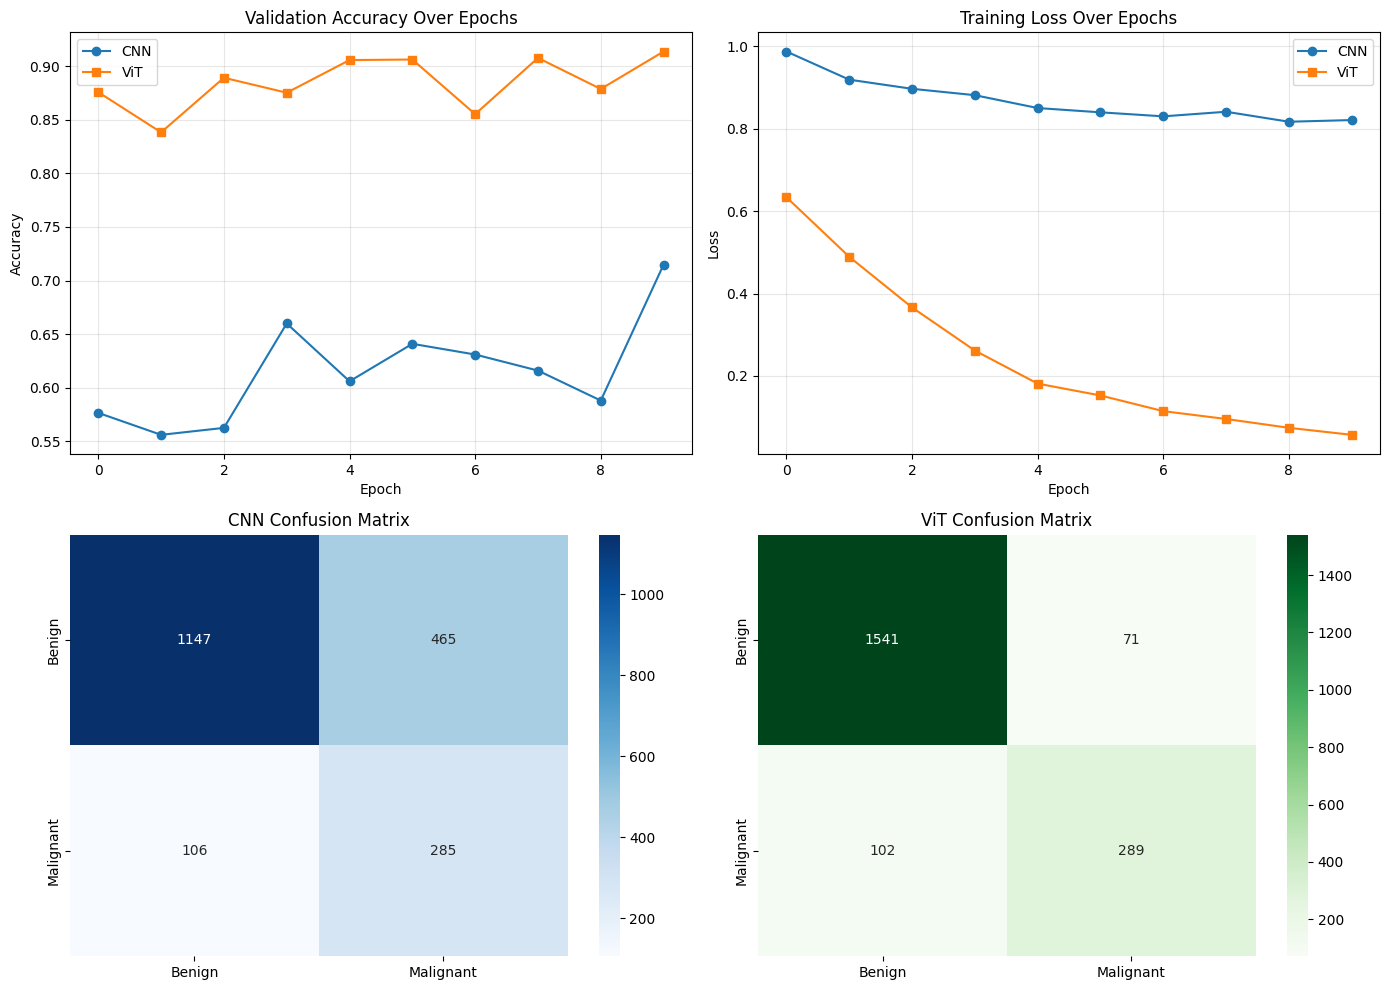

Saved ✅


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training curves
axes[0,0].plot(cnn_history['val_acc'], label='CNN', marker='o')
axes[0,0].plot(vit_history['val_acc'], label='ViT', marker='s')
axes[0,0].set_title('Validation Accuracy Over Epochs')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(cnn_history['train_loss'], label='CNN', marker='o')
axes[0,1].plot(vit_history['train_loss'], label='ViT', marker='s')
axes[0,1].set_title('Training Loss Over Epochs')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Confusion matrices
cm_cnn = confusion_matrix(all_labels_cnn, all_preds_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', ax=axes[1,0], cmap='Blues',
            xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
axes[1,0].set_title('CNN Confusion Matrix')

cm_vit = confusion_matrix(all_labels_vit, all_preds_vit)
sns.heatmap(cm_vit, annot=True, fmt='d', ax=axes[1,1], cmap='Greens',
            xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
axes[1,1].set_title('ViT Confusion Matrix')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/skin_cancer_paper/comparison_results.png', dpi=150, bbox_inches='tight')
plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

In [19]:
from google.colab import files
files.download('comparison_results.png')
print("Downloaded ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded ✅
